In [1]:
import os
import math
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
%%script echo skipping 

# Build cpp-generate-graph
subprocess.run(["make", "cpp-generate-graph"], check=True, text=True, capture_output=True)

skipping


In [3]:
def load_degseqs() -> dict[dict]:
    categories = [
        "Metabolic",
        "Tissue",
        "Protein",
        "Connectome",
        "Food",
        "Rollcall",
        "Social",
        "Route",
        "CAIDA",
        "Circuit",
        "Technological",
        "Informational",
        "Transportation",
        "Economic",
        "Other",
    ]

    degseqs = {}
    for category in categories:
        degseqs[category] = {}

    for filename in os.listdir("SFAnalysis/degreesequences"):
        try:
            with open(os.path.join("SFAnalysis/degreesequences", filename), "r") as f:
                hist = {}
                for line in f.readlines()[1:]:
                    degree, count = map(int, line.strip().split(","))
                    hist[degree] = count

                graph_nodes_num = sum(hist.values())
                graph_edges_num = (
                    sum(degree * count for degree, count in hist.items()) // 2
                )
                graph_avg_deg = (
                    graph_edges_num / graph_nodes_num if graph_nodes_num > 0 else 0
                )
                graph_param_m = math.ceil(graph_avg_deg)

                category = "Other"
                for cat in categories:
                    if cat.lower() in filename.lower():
                        category = cat
                        break

                degseqs[category][filename] = {
                    "hist": hist,
                    "nodes": graph_nodes_num,
                    "edges": graph_edges_num,
                    "avg_deg": graph_avg_deg,
                    "param_m": graph_param_m,
                }

                found = False
                for category in categories:
                    if category in filename:
                        found = True
                        break
                if not found:
                    print(f"Category not found for file {filename}")
        except Exception as e:
            print(f"Error reading file {filename}: {e}")
            continue

    return degseqs


degseqs = load_degseqs()
for category, graphs in degseqs.items():
    print(f"{category}: {len(graphs)} graphs loaded")

Metabolic: 112 graphs loaded
Tissue: 526 graphs loaded
Protein: 39 graphs loaded
Connectome: 92 graphs loaded
Food: 117 graphs loaded
Rollcall: 413 graphs loaded
Social: 213 graphs loaded
Route: 733 graphs loaded
CAIDA: 1098 graphs loaded
Circuit: 60 graphs loaded
Technological: 62 graphs loaded
Informational: 26 graphs loaded
Transportation: 171 graphs loaded
Economic: 7 graphs loaded
Other: 0 graphs loaded


In [4]:
def generate_graph(
    n0: int, n: int, m: int, deg_func: callable, egde_prob_func: callable
) -> nx.Graph:
    if n0 < 1:
        raise ValueError("n0 must be greater than or equal to 1")
    if n < n0:
        raise ValueError("n must be greater than or equal to n0")
    if 1 > m or m > n0:
        raise ValueError(
            "m must be greater than or equal to 1 and less than or equal to n0"
        )

    G = nx.complete_graph(1) if n0 == 1 else nx.star_graph(n0 - 1)

    for new_node in range(n0, n):
        G.add_node(new_node)
        nodes = list(G.nodes)
        weights = np.array([deg_func(G.degree(node)) for node in nodes])
        probabilities = weights / np.sum(weights)
        chosen_nodes = np.random.choice(nodes, m, replace=False, p=probabilities)
        added = False
        for node in chosen_nodes:
            if np.random.rand() <= egde_prob_func(G.degree(node)):
                G.add_edge(new_node, node)
                added = True

        if not added:
            G.remove_node(new_node)
    return G

In [5]:
def analyse_graph(G: nx.Graph, filename: str | None = None, degseqs: dict | None = None) -> None:
    degs_list = sorted([degree for _, degree in G.degree])
    degs = sorted(list(set(degs_list)))
    counts = [degs_list.count(deg) for deg in degs]

    cdf = np.cumsum(counts[::-1])[::-1]
    log_deg = np.log(degs)
    log_cdf = np.log(cdf)

    slope, intercept, r_value, p_value, std_err = stats.linregress(log_deg, log_cdf)
    reg_line = slope * log_deg + intercept

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.bar(
        degs, counts, width=0.8, color="skyblue", edgecolor="black", label="BA Graph's Degree Histogram"
    )
    ax1.set_xlabel("x value")
    ax1.set_ylabel("Counts", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_title(f"Histogram + log-log CDF + Linear Fit ({sum(counts)} nodes)")

    ax2 = ax1.twinx()
    # ax2.plot(degs, np.exp(log_cdf), "o", color="darkred", label="CDF >= k")
    # ax2.plot(degs, np.exp(reg_line), "--", color="red", label=f"Fit: slope={slope:.2f}")
    # ax2.set_ylabel("CDF (>= k)", color="darkred")
    # ax2.set_yscale("log")
    # ax2.set_xscale("log")
    # ax2.tick_params(axis="y", labelcolor="darkred")
    if degseqs is not None:
        ax2.plot(degseqs.keys(), degseqs.values(), "o", color="darkred", linestyle='--', label="Real Graph's Degrees")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.tight_layout()

    if filename:
        plt.savefig(filename)
    else:
        plt.show()

    plt.close(fig)

In [ ]:
if not os.path.exists("scale-free-networks-are-rare-plots"):
    os.mkdir("scale-free-networks-are-rare-plots")

for category, graphs in degseqs.items():
    print(f"Category: {category}")
    if not os.path.exists(f"scale-free-networks-are-rare-plots/{category}"):
        os.mkdir(f"scale-free-networks-are-rare-plots/{category}")
    
    for graph_name, graph_info in graphs.items():
        try:
            n = graph_info["nodes"]
            m = graph_info["param_m"]
  
            if n * m > 10000:
                print(f"Skipping graph {graph_name} due to size (n*m={n*m})")
                continue

            deg_func = lambda k: k
            edge_prob_func = lambda k: 1

            G = generate_graph(n0=m, n=n, m=m, deg_func=deg_func, egde_prob_func=edge_prob_func)
            
            analyse_graph(G, f"scale-free-networks-are-rare-plots/{category}/{graph_name}_analysis.png", graph_info["hist"])
        except Exception as e:
            print(f"Error processing graph {graph_name}: {e}")
            continue

{1: 15, 2: 3, 3: 4, 4: 8, 5: 12, 6: 13, 7: 10, 8: 14, 9: 13, 10: 16, 11: 22, 12: 16, 13: 15, 14: 15, 15: 16, 16: 9, 17: 6, 18: 8, 19: 10, 20: 7, 21: 8, 22: 6, 23: 5, 24: 3, 25: 8, 26: 3, 27: 1, 28: 2, 29: 4, 31: 2, 34: 4, 35: 3, 37: 1, 40: 1, 44: 2, 52: 1, 53: 1, 54: 3, 56: 1, 58: 1, 59: 1, 60: 1, 80: 1, 83: 1, 134: 1}
Generated graph with 297 nodes and 2319 edges
C_elegans_neurons_1986_C_elegans_Metabolic_Biological_Connectome_n3.gml_multigraphsimplified_weightedsimplified_directedtotaldistribution.txt


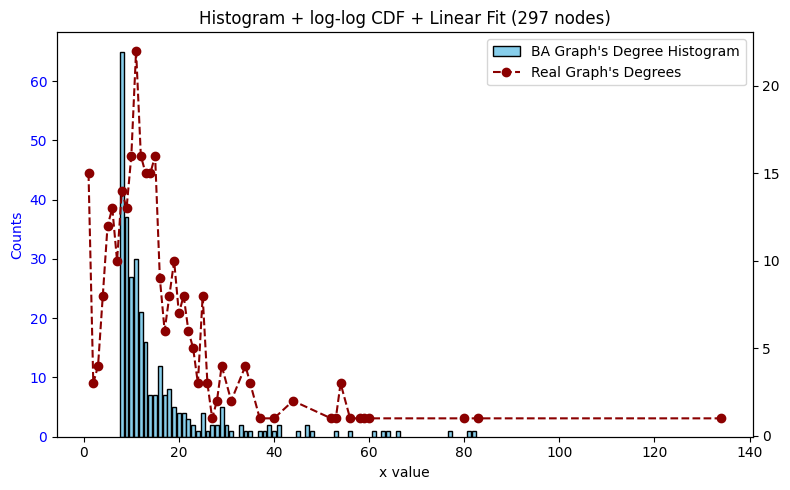

{0: 4, 1: 2, 2: 16, 3: 18, 4: 16, 5: 19, 6: 18, 7: 25, 8: 26, 9: 18, 10: 24, 11: 14, 12: 10, 13: 5, 14: 10, 15: 8, 16: 5, 17: 4, 18: 2, 19: 4, 20: 6, 21: 2, 22: 4, 25: 2, 26: 2, 27: 2, 29: 2, 30: 1, 31: 2, 33: 1, 35: 1, 39: 1, 41: 1, 60: 1, 64: 1, 80: 1, 83: 1}
Generated graph with 279 nodes and 1643 edges
C_elegans_pharynx_2011_Worm_c_elegans_herm_pharynx_1_Biological_Connectome_n3.gml_multiplexe_weight_multigraphsimplified_directedindistribution.txt


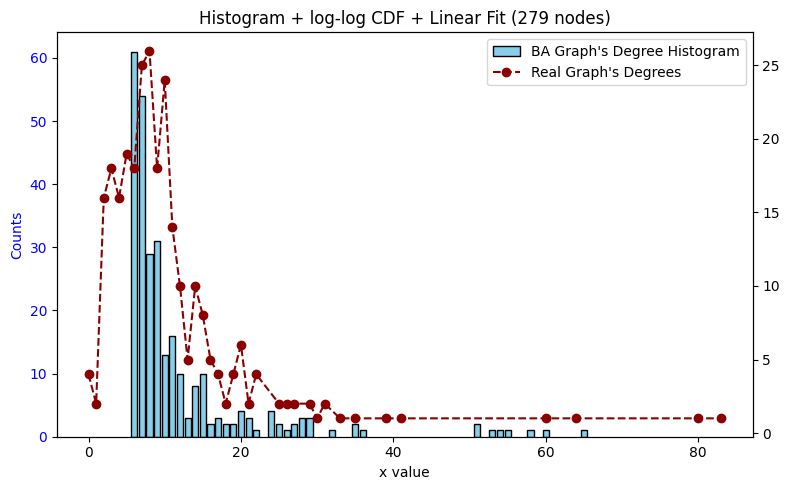

Skipping graph Cat_cerebral_hemisphere_cortex_only_Biological_Connectome_n2.gml_weighted1_directedoutdistribution.txt due to size constraints (n=46, n*m=92)
Skipping graph Mouse_visual_cortex_2011_Mouse_Mouse_visual_cortex_1_Biological_Connectome_n2.gml_multiplexunion_directedtotaldistribution.txt due to size constraints (n=29, n*m=58)
{0: 1, 1: 6, 2: 12, 3: 20, 4: 13, 5: 20, 6: 23, 7: 15, 8: 25, 9: 22, 10: 14, 11: 9, 12: 7, 13: 17, 14: 5, 15: 12, 16: 8, 17: 9, 18: 8, 19: 3, 20: 4, 21: 4, 22: 2, 23: 4, 24: 3, 25: 2, 26: 1, 28: 3, 34: 1, 37: 1, 38: 1, 40: 1, 42: 1, 51: 1, 57: 1}
Generated graph with 279 nodes and 1643 edges
C_elegans_pharynx_2011_Worm_c_elegans_herm_pharynx_1_Biological_Connectome_n3.gml_multiplexe_synapse_type_multigraphsimplified_directedoutdistribution.txt


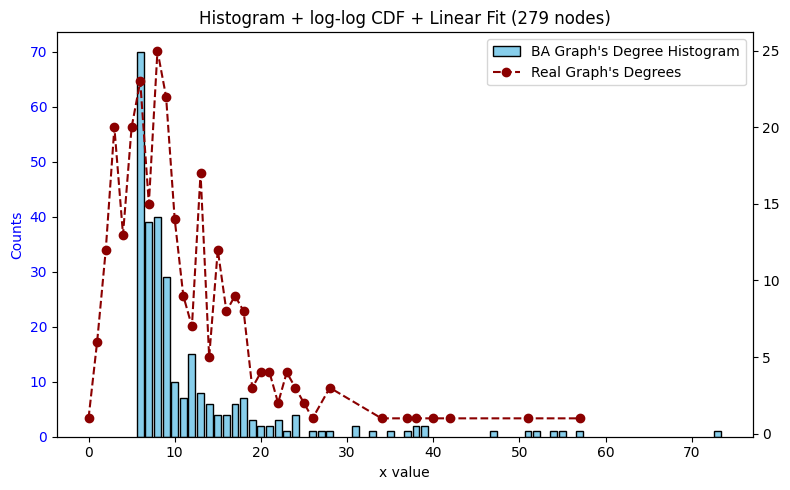

Skipping graph Rhesus_cortex_2013_Macaque_rhesus_interareal_cortical_network_2_Biological_Connectome_n2.gml_weighted3_directedtotaldistribution.txt due to size constraints (n=43, n*m=129)
Skipping graph Rhesus_cortex_2013_Macaque_rhesus_interareal_cortical_network_2_Biological_Connectome_n2.gml_weighted3_directedoutdistribution.txt due to size constraints (n=43, n*m=86)
{0: 1, 1: 6, 2: 12, 3: 20, 4: 13, 5: 20, 6: 23, 7: 15, 8: 25, 9: 22, 10: 14, 11: 9, 12: 7, 13: 17, 14: 5, 15: 12, 16: 8, 17: 9, 18: 8, 19: 3, 20: 4, 21: 4, 22: 2, 23: 4, 24: 3, 25: 2, 26: 1, 28: 3, 34: 1, 37: 1, 38: 1, 40: 1, 42: 1, 51: 1, 57: 1}
Generated graph with 279 nodes and 1643 edges
C_elegans_pharynx_2011_Worm_c_elegans_herm_pharynx_1_Biological_Connectome_n3.gml_multiplexe_weight_multigraphsimplified_directedoutdistribution.txt


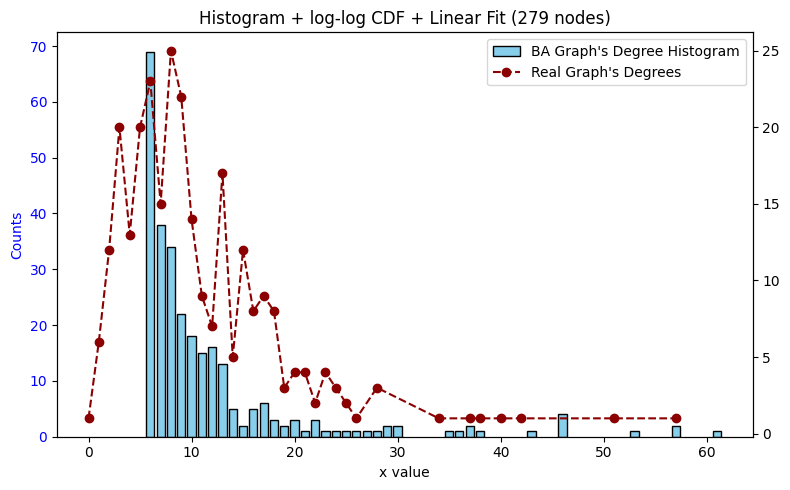

Skipping graph Cat_cerebral_hemisphere_cortex_only_Biological_Connectome_n2.gml_weighted1_directedtotaldistribution.txt due to size constraints (n=46, n*m=138)
Skipping graph Mouse_visual_cortex_2011_Mouse_Mouse_visual_cortex_1_Biological_Connectome_n2.gml_multiplex1.0_directedtotaldistribution.txt due to size constraints (n=26, n*m=52)
Skipping graph Cat_cerebral_hemisphere_cortex_only_Biological_Connectome_n2.gml_weighted1_directedindistribution.txt due to size constraints (n=46, n*m=92)
{0: 4, 1: 2, 2: 16, 3: 18, 4: 16, 5: 19, 6: 18, 7: 25, 8: 26, 9: 18, 10: 24, 11: 14, 12: 10, 13: 5, 14: 10, 15: 8, 16: 5, 17: 4, 18: 2, 19: 4, 20: 6, 21: 2, 22: 4, 25: 2, 26: 2, 27: 2, 29: 2, 30: 1, 31: 2, 33: 1, 35: 1, 39: 1, 41: 1, 60: 1, 64: 1, 80: 1, 83: 1}
Generated graph with 279 nodes and 1643 edges
C_elegans_pharynx_2011_Worm_c_elegans_herm_pharynx_1_Biological_Connectome_n3.gml_multiplexe_synapse_type_multigraphsimplified_directedindistribution.txt


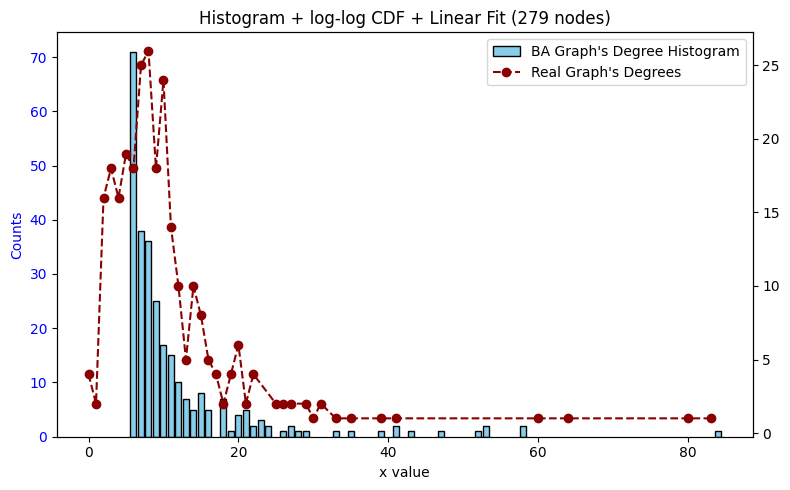

Skipping graph Rhesus_cortex_2013_Macaque_rhesus_interareal_cortical_network_2_Biological_Connectome_n2.gml_weighted3_directedindistribution.txt due to size constraints (n=43, n*m=86)
Skipping graph Smallwood_Reservoir_host-parasite_web_Smallwood_Reservoir_Biological_Food_web_n2.gml_multiplexintensity_bipartitefulldistribution.txt due to size constraints (n=31, n*m=62)
Skipping graph Small_plant-pollinator_web_Small_plant-pollinator_web_Biological_Food_web_n2.gml_bipartitefull_weightedsimplifieddistribution.txt due to size constraints (n=47, n*m=141)
Skipping graph Freshwater_stream_webs_Catlins_Biological_Food_web_n3.gml_directedtotaldistribution.txt due to size constraints (n=49, n*m=147)
Skipping graph Vazquez_Simberloff_plant-pollinator_webs_Llao_Llao_Biological_Food_web_n3.gml_bipartitea_weightedsimplifieddistribution.txt due to size constraints (n=14, n*m=14)
Skipping graph Smallwood_Reservoir_host-parasite_web_Smallwood_Reservoir_Biological_Food_web_n2.gml_multiplexprevalence_bi

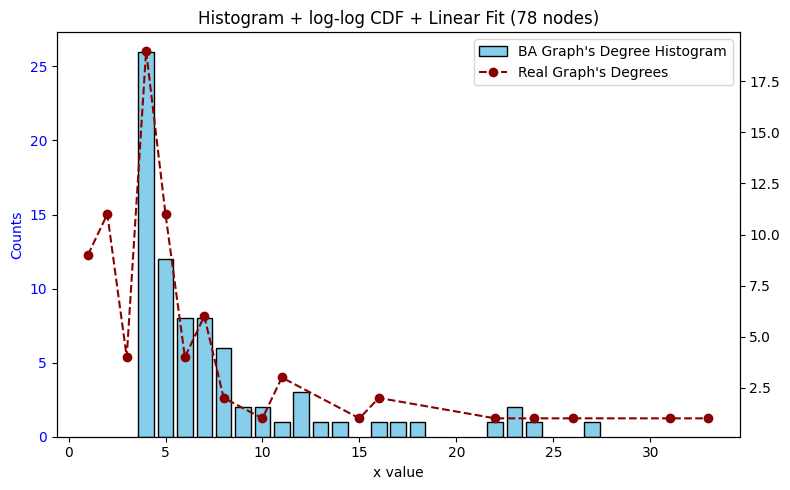

Skipping graph Olesen_plant-pollinator_web_Ile_aux_Aigrettes_Biological_Food_web_n2.gml_bipartitefull_weightedsimplifieddistribution.txt due to size constraints (n=27, n*m=54)
Skipping graph Vazquez_Simberloff_plant-pollinator_webs_Mascardi_nc_Biological_Food_web_n3.gml_bipartitea_weightedsimplifieddistribution.txt due to size constraints (n=14, n*m=14)
Skipping graph Aishihik_Lake_host-parasite_web_Aishihik_Lake_host-parasite_web_Biological_Food_web_n2.gml_multiplexintensitydistribution.txt due to size constraints (n=22, n*m=44)
Skipping graph Olesen_plant-pollinator_web_Flores_Biological_Food_web_n2.gml_bipartitefull_weightedsimplifieddistribution.txt due to size constraints (n=22, n*m=44)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_11_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=30, n*m=60)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_18_Social_Political_n2.gml_weighted3distribution.txt due to siz

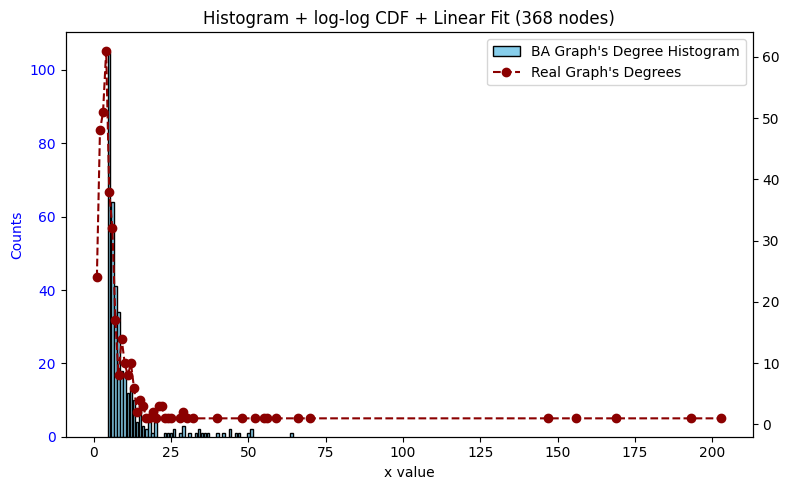

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_20_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=31, n*m=62)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_91_Social_Political_n3.gml_weighted3distribution.txt due to size constraints (n=49, n*m=147)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_95_Social_Political_n3.gml_weighted3distribution.txt due to size constraints (n=48, n*m=144)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_29_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=44, n*m=88)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_38_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=29, n*m=58)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_10_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=30, n*m=60)
Skipping graph

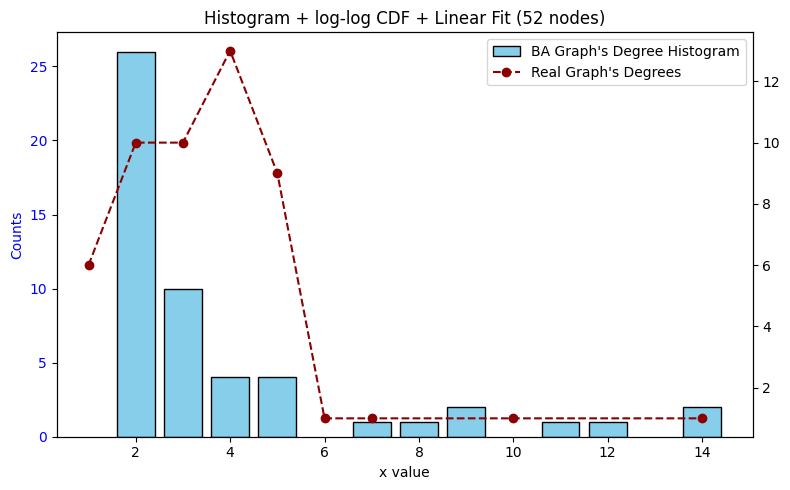

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_31_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=45, n*m=90)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_3_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=25, n*m=50)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_12_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=24, n*m=48)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_47_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=45, n*m=135)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_47_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=41, n*m=123)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_27_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=39, n*m=117)
Skipping graph

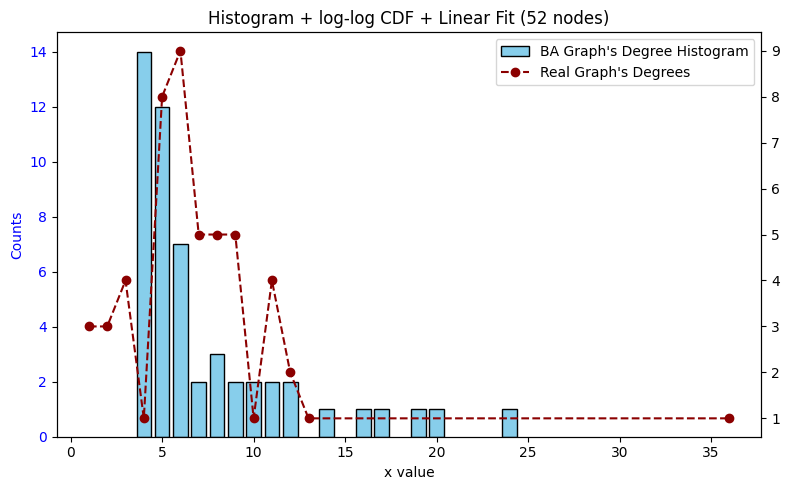

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_17_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=42, n*m=84)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_39_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=44, n*m=88)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_21_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=27, n*m=54)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_8_Social_Political_n2.gml_weighted1distribution.txt due to size constraints (n=44, n*m=176)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_48_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=48, n*m=96)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_24_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=42, n*m=126)
Skipping graph 

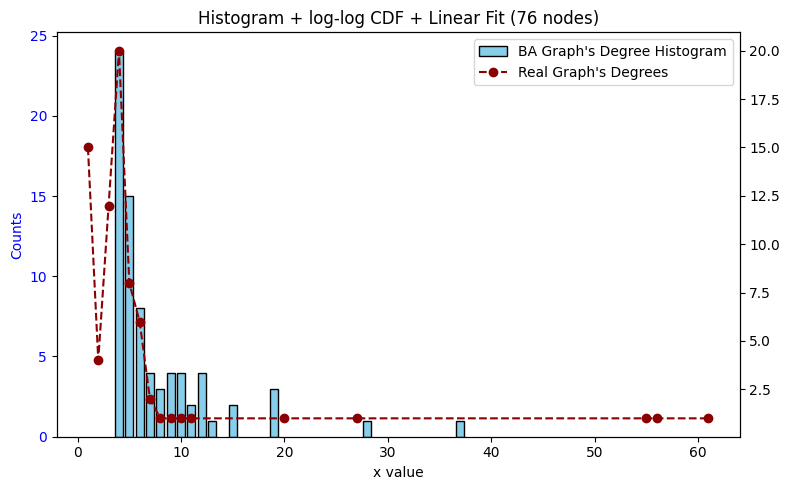

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_28_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=39, n*m=117)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_97_Social_Political_n3.gml_weighted3distribution.txt due to size constraints (n=46, n*m=138)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_7_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=26, n*m=52)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_26_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=30, n*m=60)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_41_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=45, n*m=90)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_10_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=30, n*m=60)
Skipping graph 

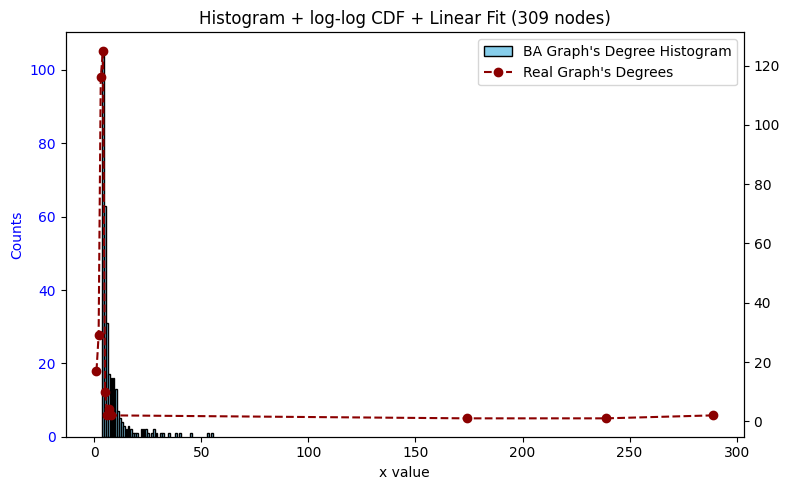

{1: 2, 2: 3, 3: 3, 4: 6, 5: 8, 6: 6, 7: 5, 8: 5, 9: 2, 10: 3, 11: 4, 12: 2, 14: 2, 38: 1}
Generated graph with 52 nodes and 195 edges
US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_17_Social_Political_n2.gml_weighted1distribution.txt


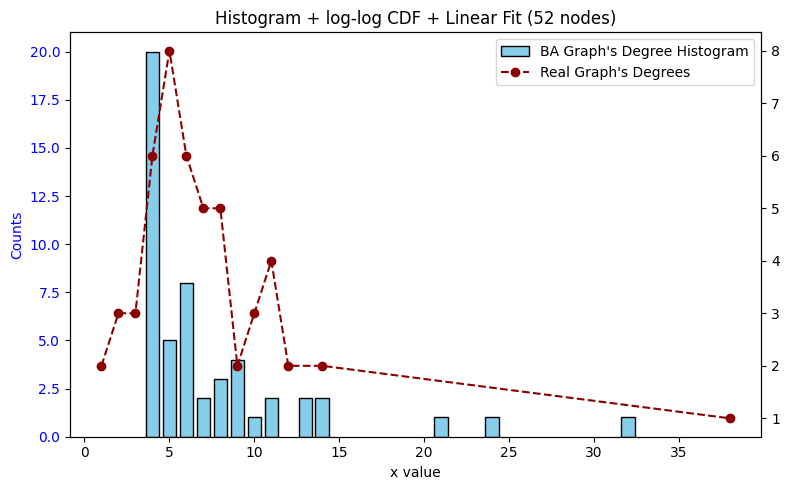

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_3_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=23, n*m=46)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_25_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=38, n*m=114)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_22_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=38, n*m=76)
{1: 10, 2: 10, 3: 19, 4: 19, 5: 16, 6: 14, 7: 21, 8: 20, 9: 19, 10: 19, 11: 22, 12: 11, 13: 12, 14: 16, 15: 9, 16: 15, 17: 11, 18: 9, 19: 5, 20: 4, 21: 8, 22: 4, 23: 7, 24: 5, 25: 2, 26: 7, 27: 2, 28: 5, 29: 2, 30: 4, 31: 3, 32: 1, 33: 5, 34: 1, 35: 3, 36: 6, 38: 3, 39: 4, 40: 2, 41: 1, 43: 2, 44: 1, 46: 1, 48: 3, 49: 1, 50: 2, 51: 3, 52: 2, 53: 2, 54: 1, 58: 2, 59: 1, 61: 2, 66: 1, 68: 1, 75: 1, 77: 1, 78: 1, 80: 1, 84: 1, 86: 1, 91: 2, 93: 1, 95: 1, 107: 1, 108: 1, 111: 1, 134: 1, 145: 1, 247: 1}
Gene

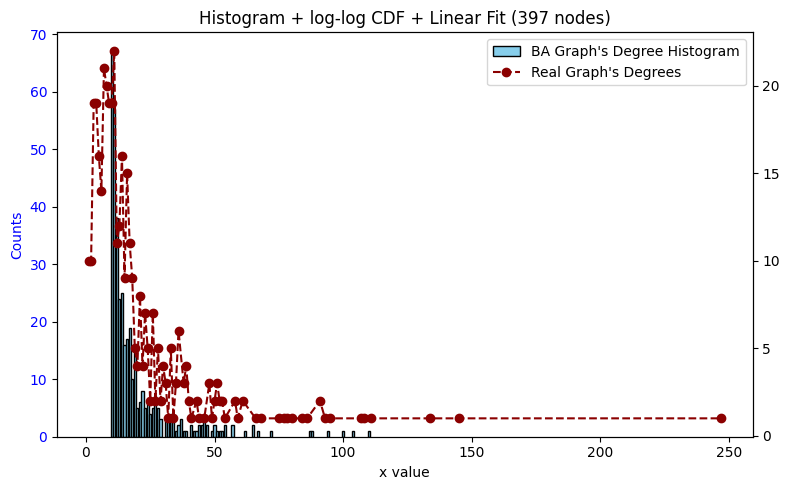

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_15_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=36, n*m=72)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_13_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=32, n*m=64)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_17_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=45, n*m=90)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_6_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=31, n*m=62)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_16_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=38, n*m=76)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_93_Social_Political_n3.gml_weighted3distribution.txt due to size constraints (n=49, n*m=147)
Skipping graph U

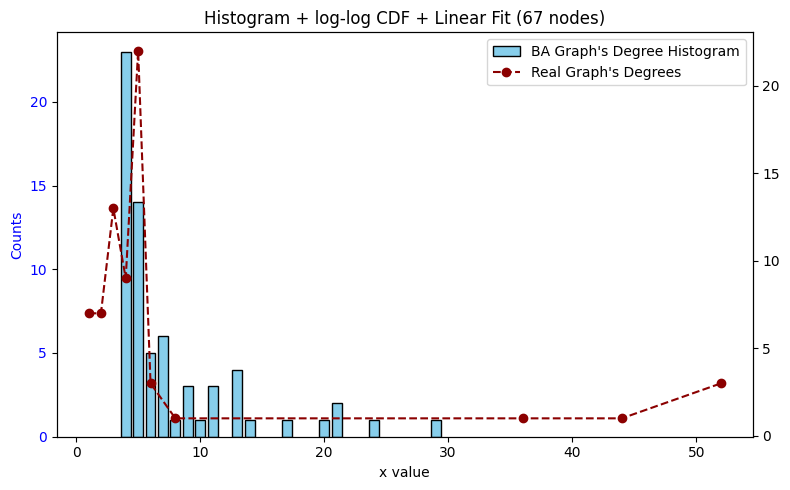

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_109_Social_Political_n3.gml_weighted3distribution.txt due to size constraints (n=49, n*m=147)
{1: 12, 2: 29, 3: 121, 4: 138, 174: 1, 239: 1, 289: 2}
Generated graph with 304 nodes and 1203 edges
US_Congress_roll-call_votes_1789-2009_Rollcall_US_House_95_Social_Political_n3.gml_weighted3distribution.txt


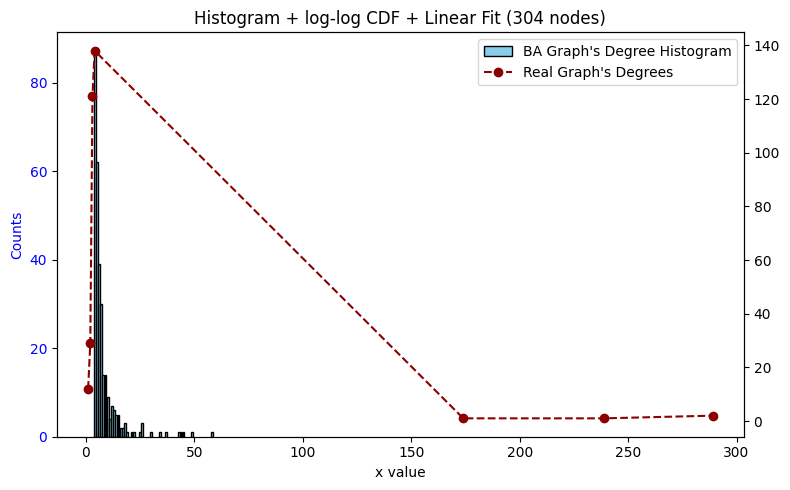

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_89_Social_Political_n3.gml_weighted3distribution.txt due to size constraints (n=44, n*m=132)
{1: 6, 2: 6, 3: 40, 4: 70, 5: 47, 6: 89, 7: 50, 8: 54, 9: 42, 10: 15, 11: 10, 12: 2, 13: 4, 14: 3, 15: 1, 20: 1, 27: 1, 47: 1, 60: 1, 64: 1, 164: 1, 183: 2, 216: 1, 230: 1, 275: 1, 406: 2, 423: 1}
Generated graph with 453 nodes and 3128 edges
US_Congress_roll-call_votes_1789-2009_Rollcall_US_House_77_Social_Political_n3.gml_weighted2distribution.txt


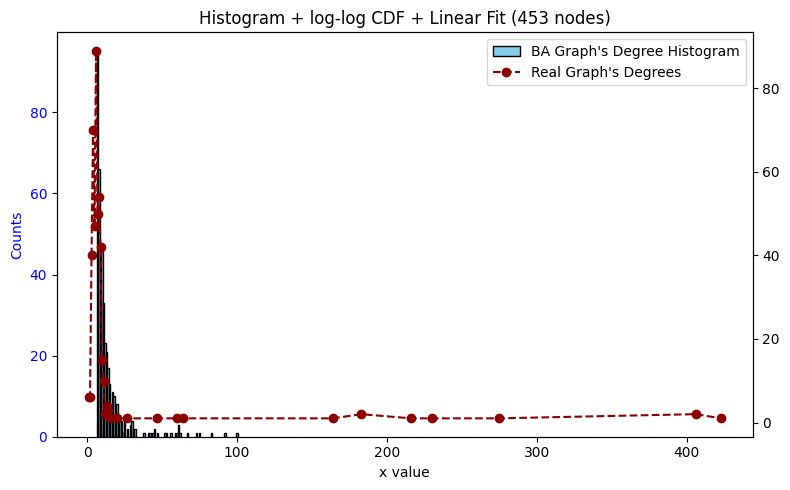

Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_34_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=35, n*m=70)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_27_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=31, n*m=62)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_28_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=34, n*m=68)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_49_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=49, n*m=98)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_34_Social_Political_n2.gml_weighted2distribution.txt due to size constraints (n=41, n*m=123)
Skipping graph US_Congress_roll-call_votes_1789-2009_Rollcall_US_Senate_14_Social_Political_n2.gml_weighted3distribution.txt due to size constraints (n=38, n*m=76)
Skipping graph 

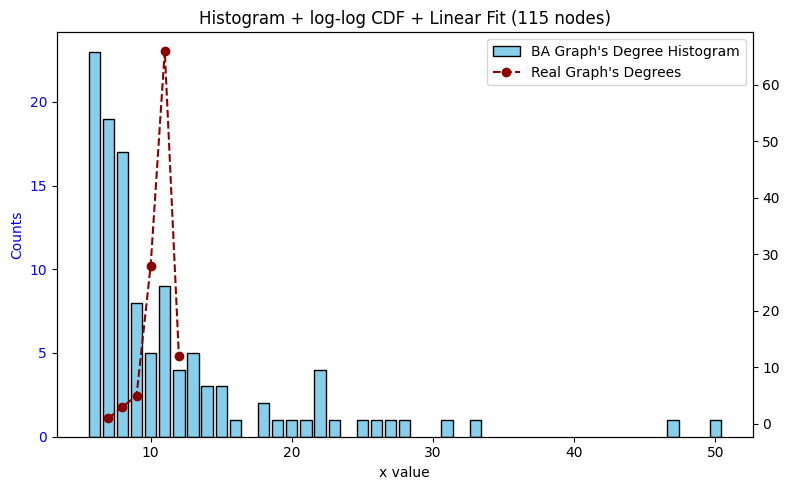

Skipping graph Alice_and_Roland_coappearances_Temporal_Alice_Network_Social_Fiction_n2.gml_multiplex8.0distribution.txt due to size constraints (n=10, n*m=20)
Skipping graph Alice_and_Roland_coappearances_Temporal_Alice_Network_Social_Fiction_n2.gml_multiplex11.0distribution.txt due to size constraints (n=9, n*m=9)
Skipping graph Facebook100_Stanford3_Social_Online_n5.gmldistribution.txt due to size constraints (n=11621, n*m=569429)
Skipping graph High_school_dynamic_contact_networks_contact_list_2012_Social_Offline_n3.gml_multiplex1353408200.0distribution.txt due to size constraints (n=4, n*m=4)
Skipping graph Padgett_Florentine_families_network_Florentine_families_network_Social_Relationships_n2.gml_multiplexunion_multigraphsimplifieddistribution.txt due to size constraints (n=16, n*m=32)
Skipping graph Facebook100_MU78_Social_Online_n5.gmldistribution.txt due to size constraints (n=15436, n*m=663748)
Skipping graph Facebook100_Cornell5_Social_Online_n5.gmldistribution.txt due to siz

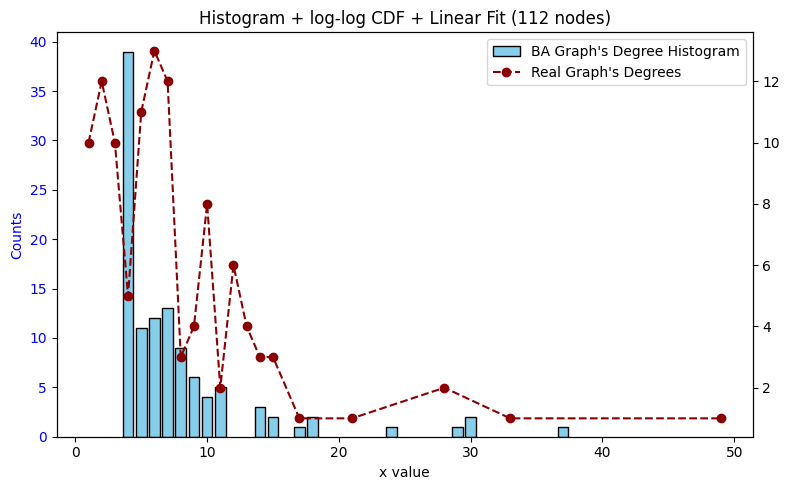

Skipping graph Web_graphs_Stanford_Berkeley_etc_Stanford_Web_Graph_Informational_Web_graph_n6.gml_directedtotaldistribution.txt due to size constraints (n=281903, n*m=2537127)
Skipping graph Web_graphs_Stanford_Berkeley_etc_Google_Web_Graph_Informational_Web_graph_n6.gml_directedoutdistribution.txt due to size constraints (n=875713, n*m=2627139)
Skipping graph Web_graphs_Stanford_Berkeley_etc_BerkStan_Web_Graph_Informational_Web_graph_n6.gml_directedtotaldistribution.txt due to size constraints (n=685230, n*m=8222760)
Skipping graph Web_graphs_Stanford_Berkeley_etc_BerkStan_Web_Graph_Informational_Web_graph_n6.gml_directedindistribution.txt due to size constraints (n=685230, n*m=4111380)
Skipping graph Web_graphs_Stanford_Berkeley_etc_Google_Web_Graph_Informational_Web_graph_n6.gml_directedtotaldistribution.txt due to size constraints (n=875713, n*m=5254278)
{1: 9, 2: 61, 3: 63, 4: 83, 5: 84, 6: 75, 7: 64, 8: 70, 9: 54, 10: 49, 11: 50, 12: 50, 13: 48, 14: 36, 15: 38, 16: 30, 17: 12, 18

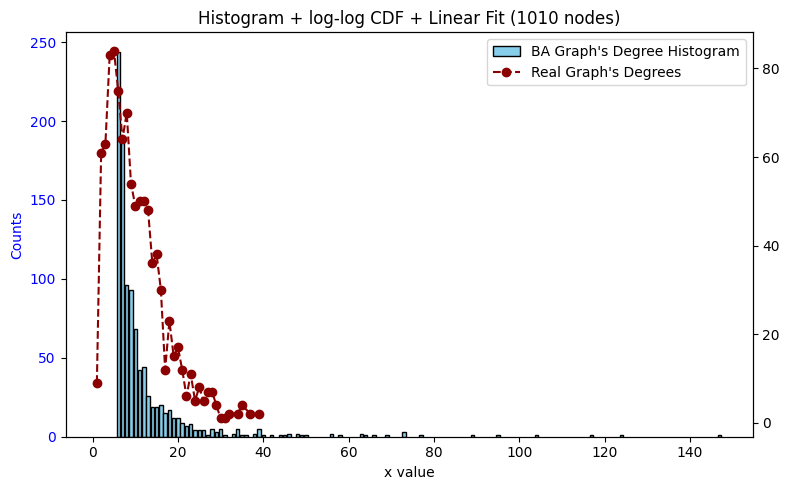

Skipping graph Web_graphs_Stanford_Berkeley_etc_Google_Web_Graph_Informational_Web_graph_n6.gml_directedindistribution.txt due to size constraints (n=875713, n*m=2627139)
Skipping graph Web_graphs_Stanford_Berkeley_etc_Stanford_Web_Graph_Informational_Web_graph_n6.gml_directedoutdistribution.txt due to size constraints (n=281903, n*m=1409515)
Skipping graph Web_graphs_Stanford_Berkeley_etc_BerkStan_Web_Graph_Informational_Web_graph_n6.gml_directedoutdistribution.txt due to size constraints (n=685230, n*m=4111380)
Skipping graph Web_graphs_Stanford_Berkeley_etc_Stanford_Web_Graph_Informational_Web_graph_n6.gml_directedindistribution.txt due to size constraints (n=281903, n*m=1409515)
{2: 1, 3: 6, 4: 14, 5: 22, 6: 11, 7: 9, 8: 8, 9: 8, 10: 2, 11: 2, 12: 2, 13: 3, 14: 1, 15: 2, 16: 3, 18: 3, 20: 1, 21: 2, 22: 1, 23: 2, 25: 2}
Generated graph with 105 nodes and 504 edges
Political_books_network_2004_Krebs_political_books_Informational_Recommendations_n3.gmldistribution.txt


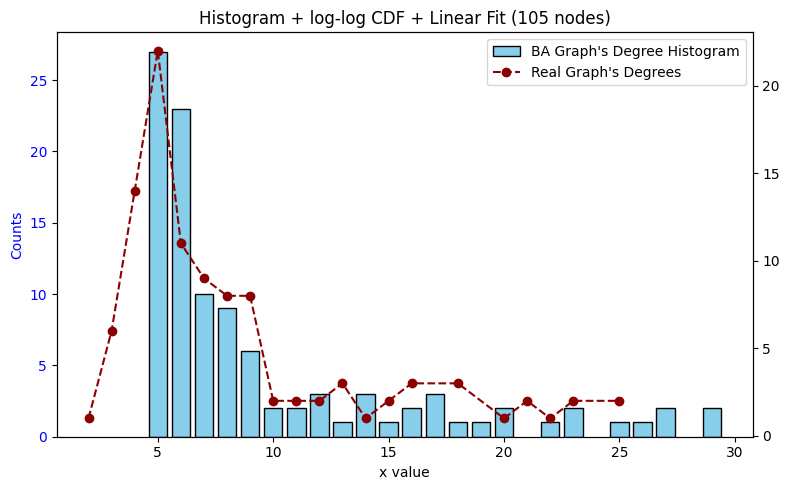

Skipping graph Amazon_book_similarities_2008_amazon-2008_Informational_Relatedness_n6.gml_multigraphsimplifieddistribution.txt due to size constraints (n=735323, n*m=3676615)
Skipping graph Webgraph_Notre_Dame_Web_graph_Notre_Dame_Informational_Web_graph_n6.gml_multigraphsimplifieddistribution.txt due to size constraints (n=325729, n*m=1302916)
Skipping graph Wikipedia_graphs_2013_spanish_wiki_2013_Informational_Web_graph_n6.gml_multigraphsimplifieddistribution.txt due to size constraints (n=970331, n*m=21347282)
Skipping graph United_States_Road_Networks_WI_Transportation_Roads_n6.gml_multiplextravel_time_multigraphsimplifieddistribution.txt due to size constraints (n=519157, n*m=1038314)
Skipping graph United_States_Road_Networks_MS_Transportation_Roads_n6.gml_multiplextravel_time_multigraphsimplifieddistribution.txt due to size constraints (n=413250, n*m=826500)
Skipping graph United_States_Road_Networks_AZ_Transportation_Roads_n6.gml_multiplexroad_category_multigraphsimplifieddistr

In [20]:
degseqs = load_degseqs()

for category, graphs in degseqs.items():
    for graph_name, graph_info in graphs.items():
        try:
            n = graph_info["nodes"]
            m = graph_info["param_m"]

            if n < 50 or n * m > 500000:
                print(f"Skipping graph {graph_name} due to size constraints (n={n}, n*m={n*m})")
                continue

            degseqs = graph_info["hist"]
            deg_count_pairs = sorted(degseqs.items(), key=lambda x: x[0])
            max_count = -1
            max_count_deg = -1
            for deg, count in deg_count_pairs:
                if count > max_count:
                    max_count = count
                    max_count_deg = deg

            num_of_degs_smaller_max_count_deg = sum(1 for deg, count in deg_count_pairs if deg < max_count_deg and deg > 0)

            if num_of_degs_smaller_max_count_deg < 3:
                continue
            else:
                print(degseqs)

            G = generate_graph(n0=m, n=n, m=m, deg_func=lambda k: k, egde_prob_func=lambda k: 1)
            print(f"Generated graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

            print(graph_name)
            analyse_graph(G, None, degseqs)
        except Exception as e:
            print(f"Error processing graph {graph_name}: {e}")
            continue